In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from matplotlib import font_manager, rc
import matplotlib.pyplot as plt

# NanumGothic 폰트 경로 자동 탐색
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_manager.fontManager.addfont(font_path)
rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
import glob

file_list = glob.glob("/content/drive/MyDrive/공모전/T6/*.csv")
print(f"T6 폴더 내 CSV 파일 개수: {len(file_list)}")
print("상위 5개 파일 확인:")
print(file_list[:5])

T6 폴더 내 CSV 파일 개수: 36
상위 5개 파일 확인:
['/content/drive/MyDrive/공모전/T6/T6_GG_TRANS_SEXAGE_SGG_INFLOW_202412_성남시.csv', '/content/drive/MyDrive/공모전/T6/T6_GG_TRANS_SEXAGE_SGG_INFLOW_202407_성남시.csv', '/content/drive/MyDrive/공모전/T6/T6_GG_TRANS_SEXAGE_SGG_INFLOW_202408_성남시.csv', '/content/drive/MyDrive/공모전/T6/T6_GG_TRANS_SEXAGE_SGG_INFLOW_202409_성남시.csv', '/content/drive/MyDrive/공모전/T6/T6_GG_TRANS_SEXAGE_SGG_INFLOW_202410_성남시.csv']


In [ ]:
import pandas as pd

# 첫 번째 파일 확인
df_sample = pd.read_csv(file_list[0])
print("첫 번째 CSV 컬럼명:")
print(df_sample.columns.tolist())

# 상위 5행 확인
print("\n첫 번째 CSV 상위 5행:")
print(df_sample.head())

첫 번째 CSV 컬럼명:
['ETL_YM', 'DOW', 'D_TIME_CD', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM', 'D_CENTER_X', 'D_CENTER_Y', 'TRANS_GB', 'SEX_CD', 'AGE_GRP', 'CNT']

첫 번째 CSV 상위 5행:
   ETL_YM DOW  D_TIME_CD  D_CTY_CD D_MEGA_NM D_CTY_NM  D_CENTER_X  D_CENTER_Y  \
0  202412   일          9     41131       경기도  성남시 수정구      964981     1937423   
1  202412   금         11     41133       경기도  성남시 중원구      970268     1937199   
2  202412   목         17     41135       경기도  성남시 분당구      965120     1931210   
3  202412   목          4     41135       경기도  성남시 분당구      965120     1931210   
4  202412   월         20     41135       경기도  성남시 분당구      965120     1931210   

   TRANS_GB SEX_CD  AGE_GRP     CNT  
0         7      F        8  131.38  
1         5      M        4    3.31  
2         2      F       10   10.75  
3         1      F        4   46.07  
4         7      F       10    3.02  


In [ ]:
print(df.columns)

Index(['ETL_YM', 'DOW', 'D_TIME_CD', 'D_CTY_CD', 'D_MEGA_NM', 'D_CTY_NM',
       'D_CENTER_X', 'D_CENTER_Y', 'PURPOSE', 'SEX_CD', 'AGE_GRP', 'CNT',
       'ETL_YM ', ' DOW ', ' D_TIME_CD ', ' D_CTY_CD ', ' D_MEGA_NM ',
       ' D_CTY_NM ', ' D_CENTER_X ', ' D_CENTER_Y ', ' PURPOSE ', ' SEX_CD ',
       ' AGE_GRP ', ' CNT'],
      dtype='object')


In [ ]:
import pandas as pd
import glob

# 1. 파일 리스트
file_list = glob.glob("/content/drive/MyDrive/공모전/T6/*.csv")

df_list = []

for file in file_list:
    temp = pd.read_csv(file)
    df_list.append(temp)

df = pd.concat(df_list, ignore_index=True)

# 2. 성별 통합: F/W → 여성, M → 남성
df['SEX_CD'] = df['SEX_CD'].replace({'F':'여성', 'W':'여성', 'M':'남성'})

# 3. 연령대 코드 변환
age_map = {
    1:'01', 2:'02', 3:'03', 4:'04', 5:'05', 6:'06',
    7:'07', 8:'08', 9:'09', 10:'10', 11:'11', 12:'12'
}
df['AGE_GRP'] = df['AGE_GRP'].map(age_map)

# 4. 이동수단 코드 변환
transport_map = {
    0:'차량', 1:'노선버스', 2:'지하철', 3:'도보',
    4:'고속버스', 5:'기차', 6:'항공', 7:'기타'
}
df['D_TIME_CD'] = df['D_TIME_CD'].map(transport_map)

# 5. 연도, 월 컬럼 생성 (ETL_YM이 202603 형태라고 가정)
df['YEAR'] = df['ETL_YM'] // 100
df['MONTH'] = df['ETL_YM'] % 100

# 6. 년도별 성비
year_sex = df.groupby(['YEAR','SEX_CD'])['CNT'].sum().unstack()
year_sex = year_sex.div(year_sex.sum(axis=1), axis=0) * 100

# 7. 년도별 이동수단 비율
year_transport = df.groupby(['YEAR','D_TIME_CD'])['CNT'].sum().unstack()
year_transport = year_transport.div(year_transport.sum(axis=1), axis=0) * 100

# 8. 년도별 연령대 비율
year_age = df.groupby(['YEAR','AGE_GRP'])['CNT'].sum().unstack()
year_age = year_age.div(year_age.sum(axis=1), axis=0) * 100

# 9. 월별 성비
month_sex = df.groupby(['YEAR','MONTH','SEX_CD'])['CNT'].sum().unstack()
month_sex = month_sex.div(month_sex.sum(axis=1), axis=0) * 100

# 10. 월별 이동수단 비율
month_transport = df.groupby(['YEAR','MONTH','D_TIME_CD'])['CNT'].sum().unstack()
month_transport = month_transport.div(month_transport.sum(axis=1), axis=0) * 100

# 11. 월별 연령대 비율
month_age = df.groupby(['YEAR','MONTH','AGE_GRP'])['CNT'].sum().unstack()
month_age = month_age.div(month_age.sum(axis=1), axis=0) * 100

# 필요 시 확인용 출력
print("년도별 성비\n", year_sex.head())
print("년도별 이동수단 비율\n", year_transport.head())
print("년도별 연령대 비율\n", year_age.head())
print("월별 성비\n", month_sex.head())
print("월별 이동수단 비율\n", month_transport.head())
print("월별 연령대 비율\n", month_age.head())

년도별 성비
 SEX_CD         남성         여성
YEAR                        
2023.0  51.423191  48.576809
2024.0  51.104365  48.895635
2025.0  51.062265  48.937735
년도별 이동수단 비율
 D_TIME_CD      고속버스        기차         기타      노선버스        도보       지하철  \
YEAR                                                                     
2023.0     4.424583  9.954547  48.696749  5.644578  3.658049  4.581309   
2024.0     4.279078  7.754640  50.366071  5.818196  3.726740  4.717208   
2025.0     4.062994  6.772723  51.237522  5.680290  3.612048  4.764568   

D_TIME_CD        차량         항공  
YEAR                            
2023.0     1.228552  21.811634  
2024.0     1.595136  21.742931  
2025.0     1.584874  22.284982  
년도별 연령대 비율
 AGE_GRP        01        02         03         04         05         06  \
YEAR                                                                      
2023.0   0.961283  7.257072  14.458656  17.345489  18.933303  19.622982   
2024.0   1.004758  7.484761  13.877235  17.495694  18.593324 

In [ ]:
# -------------------------------
# 1. 년도별 성비
# -------------------------------
print("년도별 성비 (%)")
display(year_sex.round(2))

# -------------------------------
# 2. 년도별 이동수단 비율
# -------------------------------
print("년도별 이동수단 비율 (%)")
display(year_transport.round(2))

# -------------------------------
# 3. 년도별 연령대 비율
# -------------------------------
print("년도별 연령대 비율 (%)")
display(year_age.round(2))

# -------------------------------
# 4. 월별 성비
# -------------------------------
print("월별 성비 (%)")
display(month_sex.round(2))

# -------------------------------
# 5. 월별 이동수단 비율
# -------------------------------
print("월별 이동수단 비율 (%)")
display(month_transport.round(2))

# -------------------------------
# 6. 월별 연령대 비율
# -------------------------------
print("월별 연령대 비율 (%)")
display(month_age.round(2))

년도별 성비 (%)


SEX_CD,남성,여성
YEAR,,
2023.0,51.42,48.58
2024.0,51.10,48.90
2025.0,51.06,48.94


년도별 이동수단 비율 (%)


D_TIME_CD,고속버스,기차,기타,노선버스,도보,지하철,차량,항공
YEAR,,,,,,,,
2023.0,4.42,9.95,48.70,5.64,3.66,4.58,1.23,21.81
2024.0,4.28,7.75,50.37,5.82,3.73,4.72,1.60,21.74
2025.0,4.06,6.77,51.24,5.68,3.61,4.76,1.58,22.28


년도별 연령대 비율 (%)


...

SEX_CD           남성     여성
YEAR   MONTH              
2023.0 1.0    52.11  47.89
       2.0    51.81  48.19
       3.0    51.53  48.47
       4.0    51.39  48.61
       5.0    51.28  48.72
       6.0    51.40  48.60
       7.0    51.51  48.49
       8.0    51.57  48.43
       9.0    51.23  48.77
       10.0   50.95  49.05
       11.0   51.25  48.75
       12.0   51.14  48.86
2024.0 1.0    51.43  48.57
       2.0    51.23  48.77
       3.0    50.96  49.04
       4.0    50.93  49.07
       5.0    50.73  49.27
       6.0    51.08  48.92
       7.0    51.23  48.77
       8.0    51.26  48.74
       9.0    51.22  48.78
       10.0   50.95  49.05
       11.0   51.23  48.77
       12.0   51.02  48.98
2025.0 4.0    51.08  48.92
       5.0    50.98  49.02
       6.0    51.09  48.91
       7.0    51.02  48.98
       8.0    51.14  48.86
       9.0    51.08  48.92
       10.0   50.95  49.05
       11.0   51.07  48.93
       12.0   51.15  48.85

월별 이동수단 비율 (%)


D_TIME_CD     고속버스     기차     기타  노선버스    도보   지하철    차량     항공
YEAR   MONTH                                                   
2023.0 1.0    4.95  10.35  45.22  6.96  4.27  5.49  1.55  21.21
       2.0    4.80  10.17  47.17  6.21  3.91  4.96  1.35  21.44
       3.0    4.05   9.40  50.82  5.44  3.37  4.40  1.17  21.35
       4.0    4.42   9.64  49.30  5.52  3.57  4.46  1.21  21.88
       5.0    4.39   9.90  49.14  5.35  3.44  4.36  1.17  22.24
       6.0    4.14  10.02  48.96  5.47  3.48  4.42  1.19  22.33
       7.0    4.26  10.15  48.07  5.62  3.68  4.55  1.23  22.44
       8.0    4.23  10.16  48.48  5.29  3.51  4.32  1.20  22.81
       9.0    4.83  10.27  48.20  5.36  3.69  4.39  1.17  22.09
       10.0   4.56   9.91  49.27  5.48  3.68  4.50  1.18  21.43
       11.0   4.16   9.65  51.13  5.15  3.41  4.23  1.10  21.19
       12.0   4.49   9.92  47.72  6.28  4.09  5.19  1.31  21.00
2024.0 1.0    4.75  10.33  47.56  5.80  3.96  4.72  1.31  21.58
       2.0    4.91  10.66  45.62  5.90  4.04  4.90  1.27  22.69
       3.0    4.68  10.01  49.47  5.36  3.50  4.35  1.15  21.48
       4.0    4.03   9.42  50.59  4.96  3.36  4.28  1.09  22.27
       5.0    3.49   5.94  55.22  4.79  2.93  3.92  1.05  22.66
       6.0    4.10   6.98  49.90  6.22  3.88  4.98  1.85  22.07
       7.0    3.88   6.53  52.26  5.68  3.60  4.56  1.74  21.76
       8.0    4.22   6.87  50.40  6.01  3.77  4.84  1.84  22.06
       9.0    4.33   6.92  49.90  6.27  3.99  5.05  1.91  21.63
       10.0   5.00   7.70  49.54  6.00  3.96  4.92  1.83  21.05
       11.0   3.94   6.51  52.27  6.00  3.64  4.70  1.79  21.14
       12.0   4.07   6.45  50.92  6.52  3.97  5.20  1.94  20.92
2025.0 4.0    3.88   6.36  53.22  5.31  3.24  4.38  1.48  22.14
       5.0    3.92   6.74  51.11  5.90  3.63  4.88  1.66  22.16
       6.0    4.28   6.98  50.50  5.95  3.65  4.87  1.69  22.08
       7.0    3.84   6.91  51.48  5.60  3.52  4.67  1.57  22.42
       8.0    4.25   7.00  49.53  5.90  3.79  5.02  1.65  22.85
       9.0    4.11   6.61  52.58  5.07  3.39  4.36  1.38  22.50
       10.0   4.47   7.06  49.84  5.95  3.88  5.05  1.66  22.10
       11.0   3.94   6.70  51.66  5.55  3.63  4.74  1.55  22.22
       12.0   3.96   6.59  50.98  5.96  3.83  4.99  1.65  22.04

월별 연령대 비율 (%)


AGE_GRP         01    02     03     04     05     06     07    08    09    10  \
YEAR   MONTH                                                                    
2023.0 1.0    0.82  6.68  14.91  17.93  19.43  19.82  14.06  5.04  1.23  0.07   
       2.0    0.84  6.40  14.59  17.88  19.37  19.82  14.39  5.32  1.32  0.07   
       3.0    0.96  7.43  14.70  17.29  19.02  19.54  14.30  5.35  1.35  0.07   
       4.0    1.00  7.38  14.59  17.26  18.95  19.63  14.40  5.34  1.37  0.07   
       5.0    1.00  7.50  14.54  17.12  18.77  19.61  14.49  5.48  1.42  0.07   
       6.0    0.98  7.21  14.39  17.34  18.93  19.64  14.53  5.51  1.41  0.07   
       7.0    0.96  7.15  14.29  17.46  19.00  19.78  14.47  5.43  1.38  0.07   
       8.0    0.98  6.99  14.20  17.39  18.94  19.84  14.63  5.55  1.41  0.08   
       9.0    1.03  7.58  14.46  17.01  18.72  19.48  14.52  5.64  1.47  0.08   
       10.0   0.99  7.59  14.26  16.93  18.59  19.50  14.70  5.84  1.52  0.08   
       11.0   0.98  7.56  14.44  17.31  18.76  19.35  14.44  5.61  1.47  0.08   
       12.0   0.98  7.49  14.17  17.33  18.78  19.49  14.61  5.63  1.44  0.08   
2024.0 1.0    0.99  6.78  14.03  17.74  18.91  19.62  14.71  5.68  1.46  0.08   
       2.0    1.00  6.76  13.94  17.56  18.72  19.60  14.90  5.87  1.55  0.08   
       3.0    1.10  7.81  13.98  16.98  18.47  19.30  14.81  5.92  1.54  0.08   
       4.0    1.10  7.57  13.85  17.09  18.43  19.33  14.88  6.06  1.60  0.09   
       5.0    1.08  7.91  14.02  17.06  18.35  19.28  14.68  5.98  1.56  0.08   
       6.0    1.05  7.56  13.86  17.51  18.65  19.12  14.56  5.97  1.61  0.09   
       7.0    0.99  7.39  13.79  17.87  18.80  19.23  14.40  5.88  1.55  0.09   
       8.0    1.00  7.37  13.81  17.80  18.67  19.25  14.53  5.92  1.55  0.09   
       9.0    0.97  7.72  14.09  17.47  18.44  19.11  14.51  5.99  1.61  0.09   
       10.0   0.95  7.65  13.76  17.45  18.42  19.13  14.72  6.17  1.67  0.09   
       11.0   0.92  7.67  13.78  17.70  18.67  19.07  14.48  6.00  1.61  0.09   
       12.0   0.90  7.51  13.63  17.72  18.60  19.10  14.77  6.09  1.59  0.09   
2025.0 4.0    0.96  7.58  13.31  17.62  18.47  19.08  14.72  6.47  1.69  0.10   
       5.0    0.97  7.93  13.20  17.33  18.16  19.01  14.91  6.63  1.76  0.10   
       6.0    0.95  7.59  13.22  17.50  18.32  19.10  14.89  6.60  1.72  0.10   
       7.0    0.60  5.98  13.05  19.78  18.52  19.24  15.35  5.93  1.45  0.09   
       8.0    0.94  7.62  12.98  17.76  18.38  19.05  14.85  6.59  1.73  0.10   
       9.0    0.90  7.74  13.29  17.69  18.32  18.82  14.72  6.64  1.76  0.11   
       10.0   0.88  7.84  13.06  17.45  18.10  18.98  15.02  6.76  1.80  0.11   
       11.0   0.85  7.91  12.94  17.51  18.22  18.84  15.02  6.80  1.79  0.11   
       12.0   0.83  7.71  12.78  17.55  18.37  19.04  15.09  6.79  1.74  0.10   

AGE_GRP        11   12  
YEAR   MONTH            
2023.0 1.0    0.0  NaN  
       2.0    0.0  NaN  
       3.0    0.0  NaN  
       4.0    0.0  NaN  
       5.0    0.0  NaN  
       6.0    0.0  NaN  
       7.0    0.0  NaN  
       8.0    0.0  NaN  
       9.0    0.0  NaN  
       10.0   0.0  NaN  
       11.0   0.0  NaN  
       12.0   0.0  NaN  
2024.0 1.0    0.0  NaN  
       2.0    0.0  NaN  
       3.0    0.0  NaN  
       4.0    0.0  NaN  
       5.0    0.0  NaN  
       6.0    0.0  NaN  
       7.0    0.0  NaN  
       8.0    0.0  NaN  
       9.0    0.0  0.0  
       10.0   0.0  NaN  
       11.0   0.0  NaN  
       12.0   0.0  NaN  
2025.0 4.0    0.0  NaN  
       5.0    0.0  NaN  
       6.0    0.0  NaN  
       7.0    0.0  NaN  
       8.0    0.0  NaN  
       9.0    0.0  NaN  
       10.0   0.0  0.0  
       11.0   0.0  NaN  
       12.0   0.0  NaN

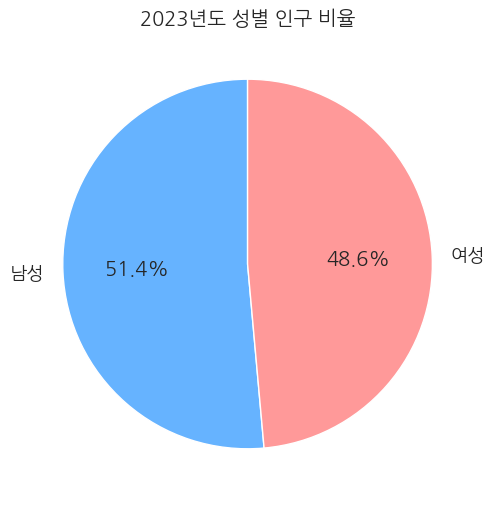

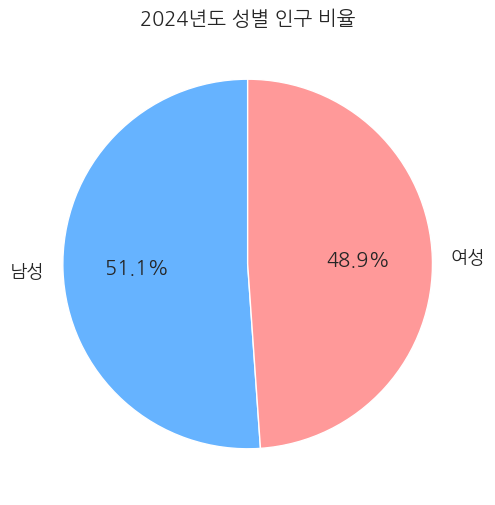

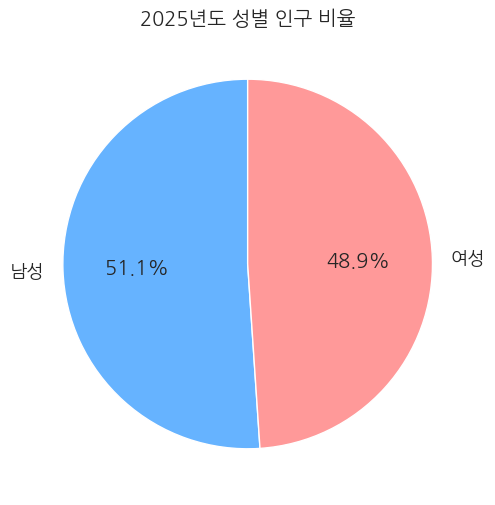

년도별 성비 원형 그래프 생성 완료.


In [ ]:
import matplotlib.pyplot as plt

# Ensure Korean font is applied for plots within this cell
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # y축 라벨 음수 부호 처리

# 년도별 성비 원형 그래프 생성
for year in year_sex.index:
    plt.figure(figsize=(6, 6))
    # '남성', '여성' 컬럼만 선택하여 파이 차트 그리기
    data_to_plot = year_sex.loc[year, ['남성', '여성']]
    data_to_plot.plot.pie(autopct='%1.1f%%', startangle=90, colors=['#66b3ff', '#ff9999'])
    plt.title(f'{int(year)}년도 성별 인구 비율')
    plt.ylabel('') # y축 라벨 제거
    plt.show()

print("년도별 성비 원형 그래프 생성 완료.")

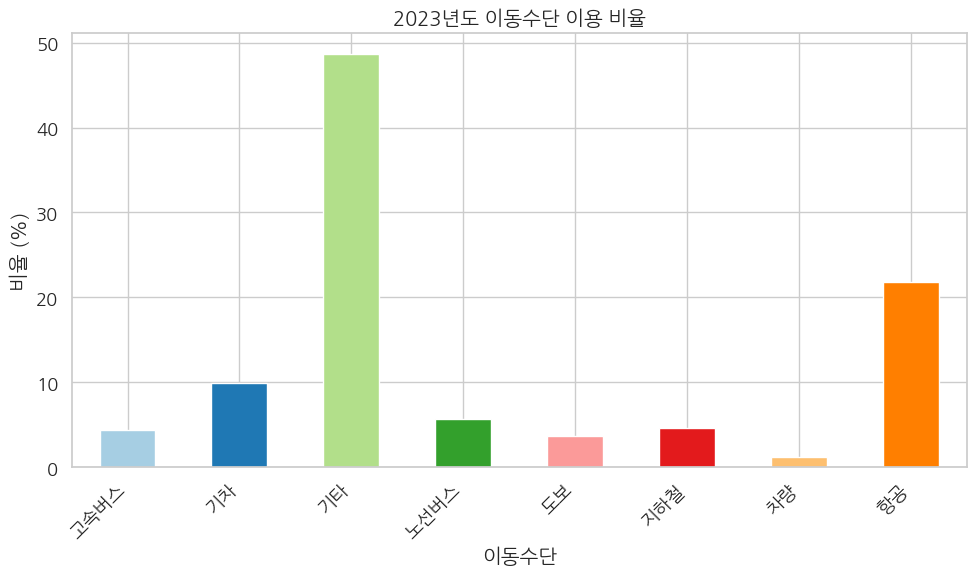

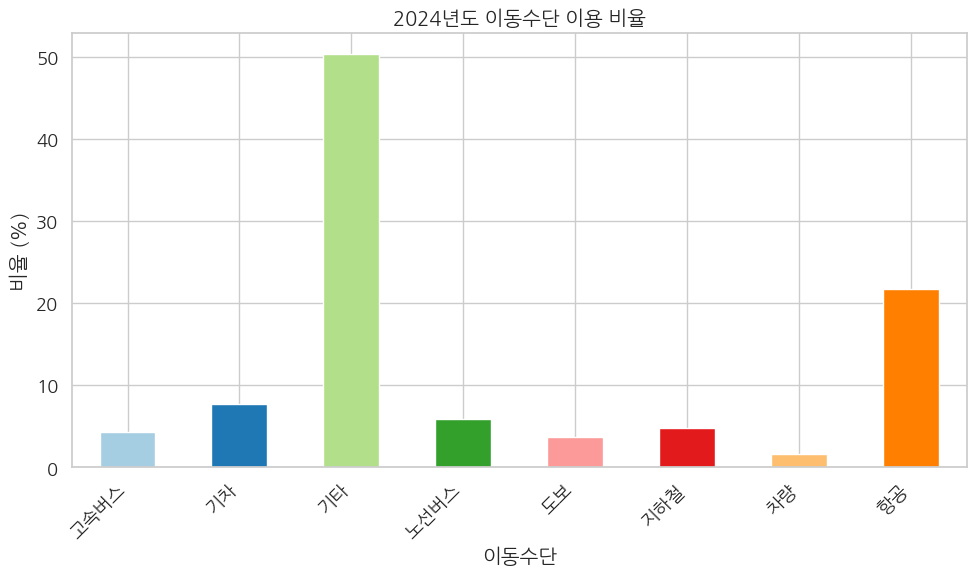

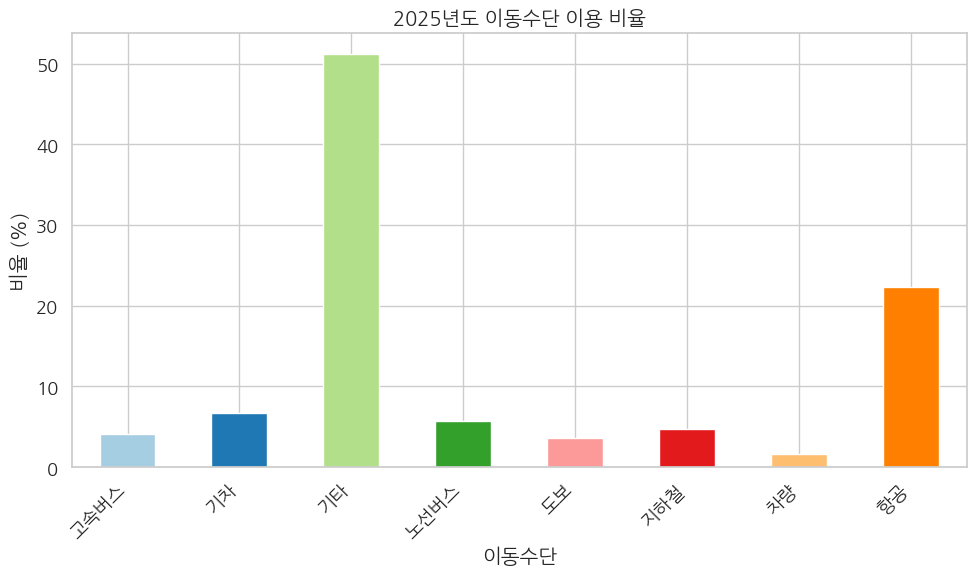

년도별 이동수단 이용 비율 막대 그래프 생성 완료.


In [ ]:
import matplotlib.pyplot as plt

# Ensure Korean font is applied for plots within this cell
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # y축 라벨 음수 부호 처리

# 년도별 이동수단 이용 비율 막대 그래프 생성
for year in year_transport.index:
    plt.figure(figsize=(10, 6))
    # 이동수단 컬럼들을 선택하여 막대 그래프 그리기 (NaN 값은 제외)
    data_to_plot = year_transport.loc[year].dropna()
    data_to_plot.plot.bar(figsize=(10,6), color=plt.cm.Paired(range(len(data_to_plot))))
    plt.title(f'{int(year)}년도 이동수단 이용 비율')
    plt.xlabel('이동수단')
    plt.ylabel('비율 (%)')
    plt.xticks(rotation=45, ha='right') # x축 레이블 회전
    plt.tight_layout() # 레이아웃 조정
    plt.show()

print("년도별 이동수단 이용 비율 막대 그래프 생성 완료.")

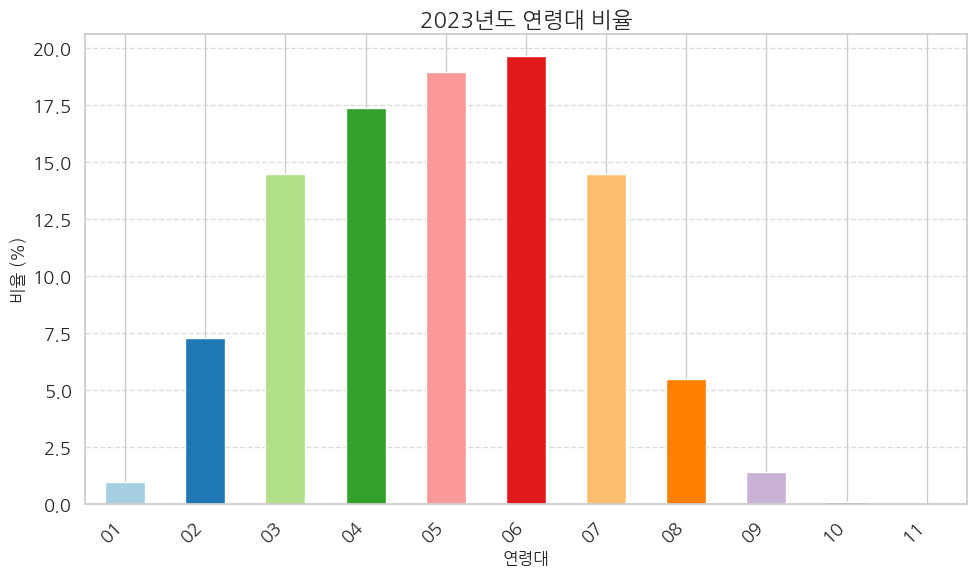

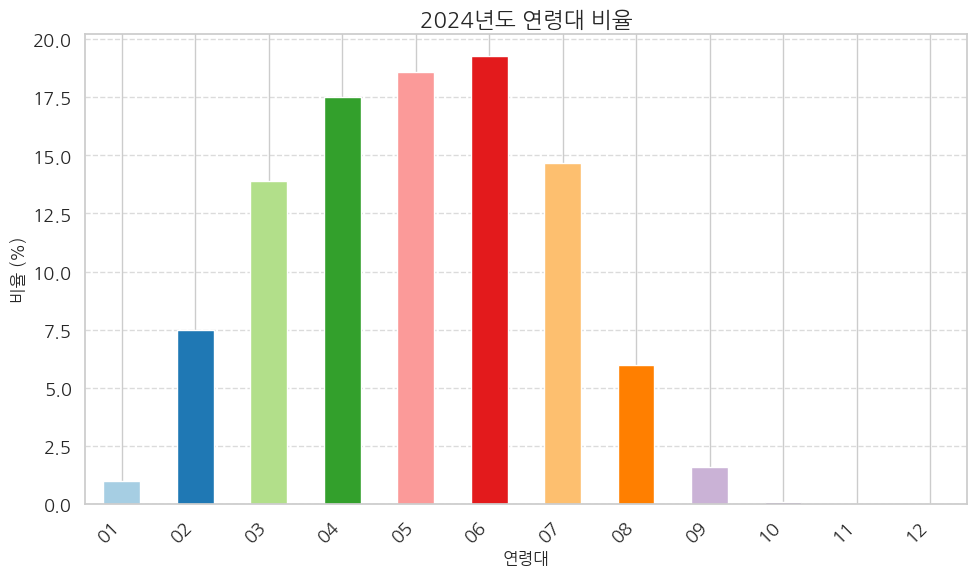

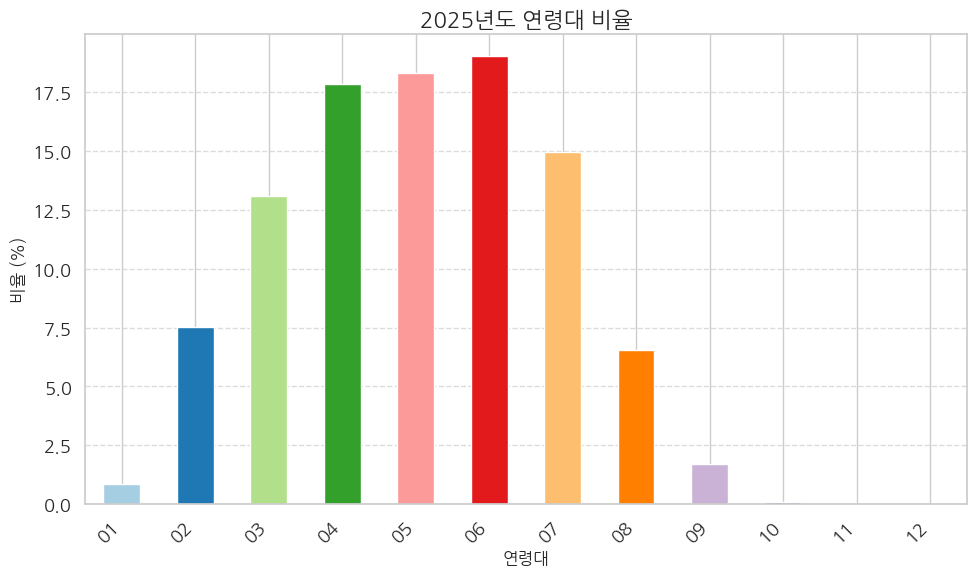

년도별 연령대 비율 막대 그래프 생성 완료.


In [87]:
import matplotlib.pyplot as plt

# Ensure Korean font is applied for plots within this cell
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # y축 라벨 음수 부호 처리

# 년도별 연령대 비율 막대 그래프 생성
for year in year_age.index:
    plt.figure(figsize=(10, 6)) # figsize를 막대 그래프에 맞게 조정
    data_to_plot = year_age.loc[year]
    # 0이거나 NaN인 값은 그래프에서 제외
    data_to_plot = data_to_plot[data_to_plot > 0].dropna()

    # 막대 그래프 그리기
    data_to_plot.plot.bar(
        color=plt.cm.Paired(range(len(data_to_plot))) # 다양한 색상 사용
    )

    plt.title(f'{int(year)}년도 연령대 비율', fontsize=16)
    plt.xlabel('연령대', fontsize=12)
    plt.ylabel('비율 (%)', fontsize=12)
    plt.xticks(rotation=45, ha='right') # x축 레이블 회전
    plt.grid(axis='y', linestyle='--', alpha=0.7) # y축 그리드 추가
    plt.tight_layout() # 레이아웃 조정
    plt.show()

print("년도별 연령대 비율 막대 그래프 생성 완료.")

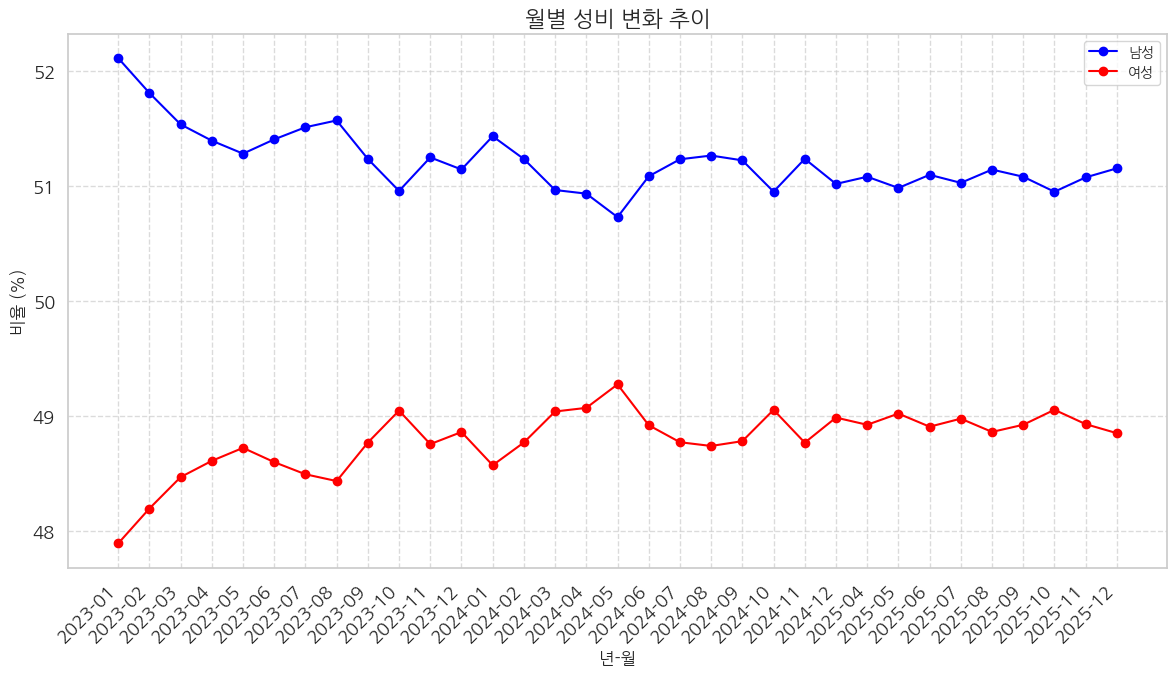

월별 성비 변화 추이 선 그래프 생성 완료.


In [ ]:
import matplotlib.pyplot as plt

# Ensure Korean font is applied for plots within this cell
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # y축 라벨 음수 부호 처리

# 월별 성비 변화 추이 선 그래프 생성
plt.figure(figsize=(12, 7))

# x축 레이블 준비: 'YYYY-MM' 형식
x_labels = [f'{int(year)}-{int(month):02d}' for year, month in month_sex.index]

# '남성'과 '여성' 데이터 플로팅
plt.plot(x_labels, month_sex['남성'], marker='o', label='남성', color='blue')
plt.plot(x_labels, month_sex['여성'], marker='o', label='여성', color='red')

plt.title('월별 성비 변화 추이', fontsize=16)
plt.xlabel('년-월', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # x축 레이블 회전
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=10)
plt.tight_layout() # 레이아웃 조정
plt.show()

print("월별 성비 변화 추이 선 그래프 생성 완료.")

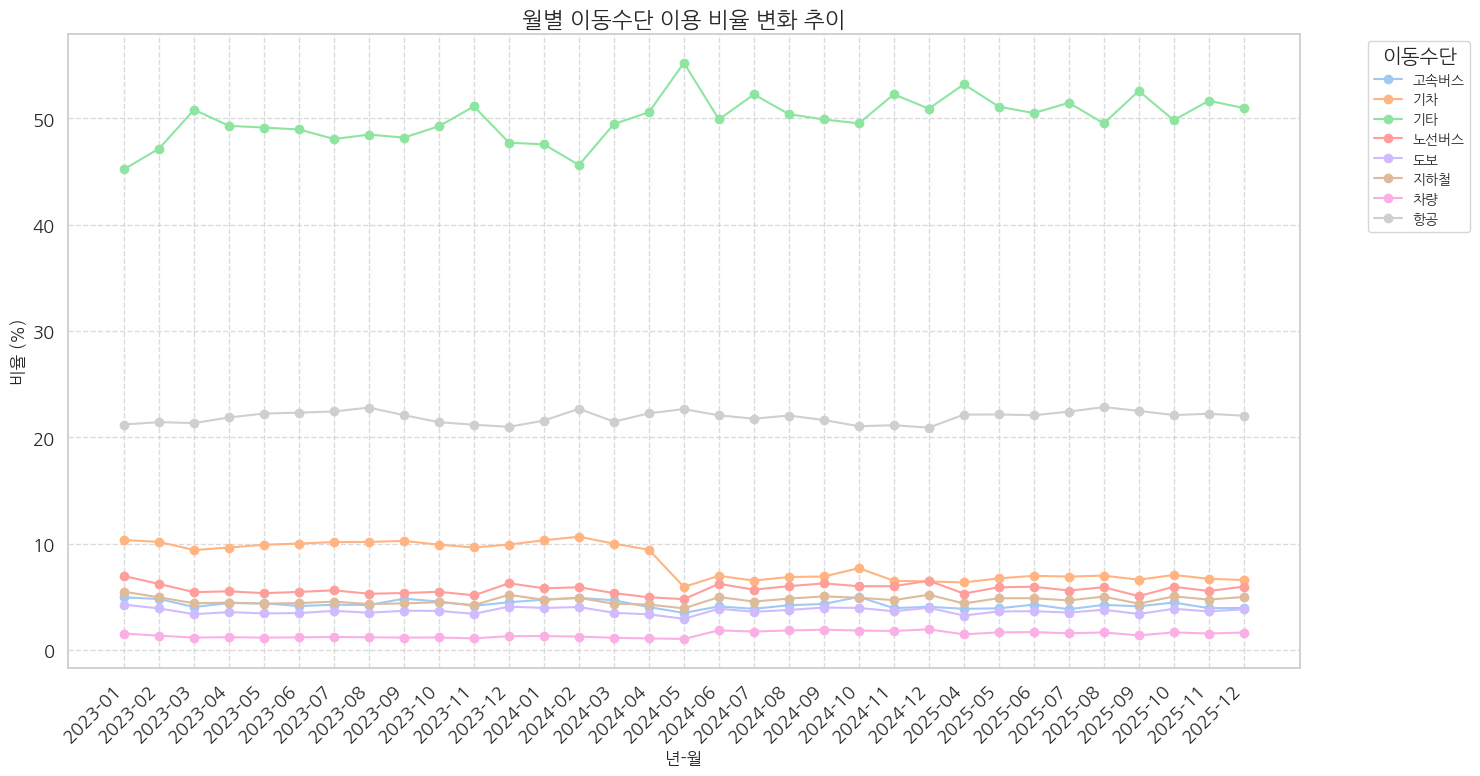

월별 이동수단 이용 비율 변화 추이 선 그래프 생성 완료.


In [ ]:
import matplotlib.pyplot as plt

# Ensure Korean font is applied for plots within this cell
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # y축 라벨 음수 부호 처리

# 월별 이동수단 이용 비율 변화 추이 선 그래프 생성
plt.figure(figsize=(15, 8)) # 그래프 크기 조정

# x축 레이블 준비: 'YYYY-MM' 형식
x_labels = [f'{int(year)}-{int(month):02d}' for year, month in month_transport.index]

# 각 이동수단(컬럼)에 대해 선 그래프 생성
for column in month_transport.columns:
    plt.plot(x_labels, month_transport[column], marker='o', label=column)

plt.title('월별 이동수단 이용 비율 변화 추이', fontsize=16)
plt.xlabel('년-월', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # x축 레이블 회전
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='이동수단', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout() # 레이아웃 조정
plt.show()

print("월별 이동수단 이용 비율 변화 추이 선 그래프 생성 완료.")

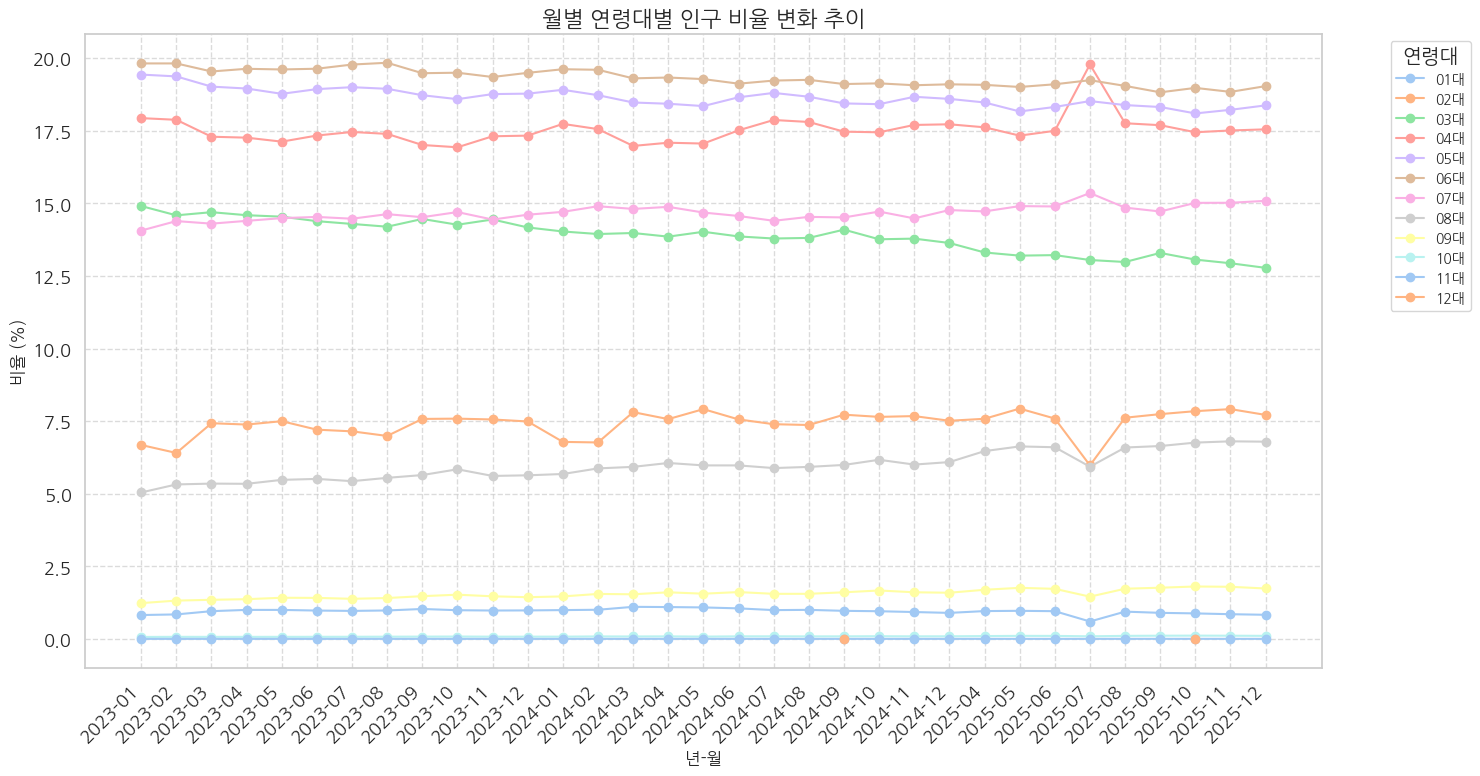

월별 연령대별 인구 비율 변화 추이 선 그래프 생성 완료.


In [ ]:
import matplotlib.pyplot as plt

# Ensure Korean font is applied for plots within this cell
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False # y축 라벨 음수 부호 처리

# 월별 연령대 비율 변화 추이 선 그래프 생성
plt.figure(figsize=(15, 8)) # 그래프 크기 조정

# x축 레이블 준비: 'YYYY-MM' 형식
x_labels = [f'{int(year)}-{int(month):02d}' for year, month in month_age.index]

# 각 연령대(컬럼)에 대해 선 그래프 생성
for column in month_age.columns:
    plt.plot(x_labels, month_age[column], marker='o', label=f'{column}대')

plt.title('월별 연령대별 인구 비율 변화 추이', fontsize=16)
plt.xlabel('년-월', fontsize=12)
plt.ylabel('비율 (%)', fontsize=12)
plt.xticks(rotation=45, ha='right') # x축 레이블 회전
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='연령대', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.tight_layout() # 레이아웃 조정
plt.show()

print("월별 연령대별 인구 비율 변화 추이 선 그래프 생성 완료.")